<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo de Laboratorio Nº1
#### Grupo Nº1

### Consigna

<div align="center">

|  Grupo  |     Función de aproximación     | Frecuencia de corte | Frecuencia de stop | Atenuación máxima en banda de paso | Atenuación mínima en banda de stop |
|:------:|:-------------------------------:|:-------------------:|:------------------:|:----------------------------------:|:----------------------------------:|
|   1    |           Chebyshev             |      1.5 kHz        |      4.5 kHz       |              0.5 dB                |               16 dB                |

</div>

In [1]:
from IPython.display import HTML

file = "./TPL1_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt
import utils.synth as usynth
import utils.tools as ut

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from pytc2.sistemas_lineales import plot_plantilla, bodePlot

## Análisis de la Transferencia
Se Utilizan los valores de $Q$, $\omega_0$ y $k$ obtenidos manualmente (PDF adjunto).

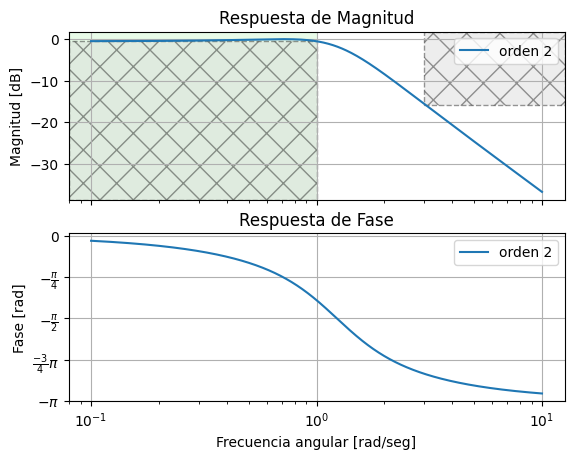

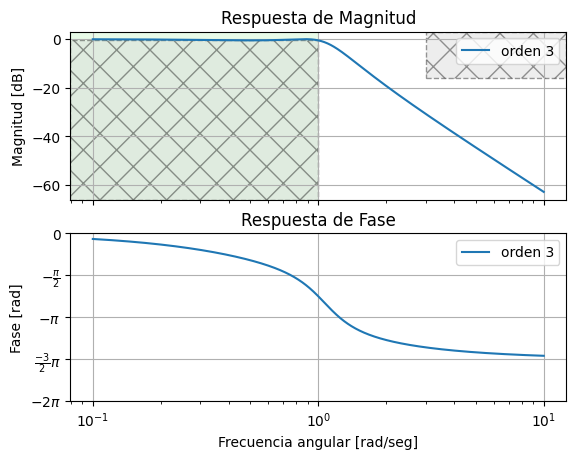

In [3]:
Q = 0.863
w0 = np.sqrt(1.5162)
k = 0.9438


num = np.array([k * w0**2])
den = np.array([1.0, w0 / Q, w0**2])

H = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(
    H,
    xaxis="omega",
    filter_description="orden 2",
    fs=2 * np.pi,
)

plt.sca(axes_hdl[0])

plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)


c = 1.2529
a = 0.7157
b = 1.5349

num = np.array([a])
den = np.array([1.0, c, b, a])

H = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(
    H,
    xaxis="omega",
    filter_description="orden 3",
    fs=2 * np.pi,
)

plt.sca(axes_hdl[0])

plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)

# Circuito Propuesto

Se utiliza la transferencia de un Ackerberg-Mossberg

$$
H(s) = - \frac{R_3}{R_1} \;  \cfrac{\frac{1}{{R_3}^2 \, C^2}}{s^2 + s \, \frac{1}{R_2\, C} + \frac{1}{{R_3}^2 \, C^2}}
$$

Por lo tanto se tiene la siguiente expresión simplificada:

$$
H(s) = - k \;  \cfrac{{\omega_0}^2}{s^2 + s \, \frac{\omega_0}{Q} + {\omega_0}^2}
$$

Siendo los parámetros característicos del filtro:

$$k = \frac{R_3}{R_1}$$

$$\omega_0 =  \frac{1}{R_3 \, C}$$

$$Q =  \frac{R_2}{R_3}$$

# Síntesis - Orden 2

$$\Omega_{\omega_0} = \omega_0$$

$$\Omega_{Z} = R_3 = 1$$

Quedando con la siguiente transferencia:

$$
H(s) = - \frac{1}{R_1} \;  \cfrac{1}{s^2 + s \, \frac{1}{R_2} + 1}
$$

Siendo los parámetros característicos del filtro:

$$k = \cfrac{1}{R_1}$$

$$\omega_0 =  \frac{1}{C}$$

$$Q =  R_2$$

Se requiere cumplir con los siguientes valores para cumplir con la transferencia deseada:

$$k = 0.9438$$
  
$$Q = 0.863$$

$$\omega_0 = \sqrt{1.5162}$$

$$\Omega_Z = R_3 == 1$$

$$H(s) = -1.35E^{8} \frac{1}{1s^2 + 1.34E^{4}s + 1.35E^{8}}$$

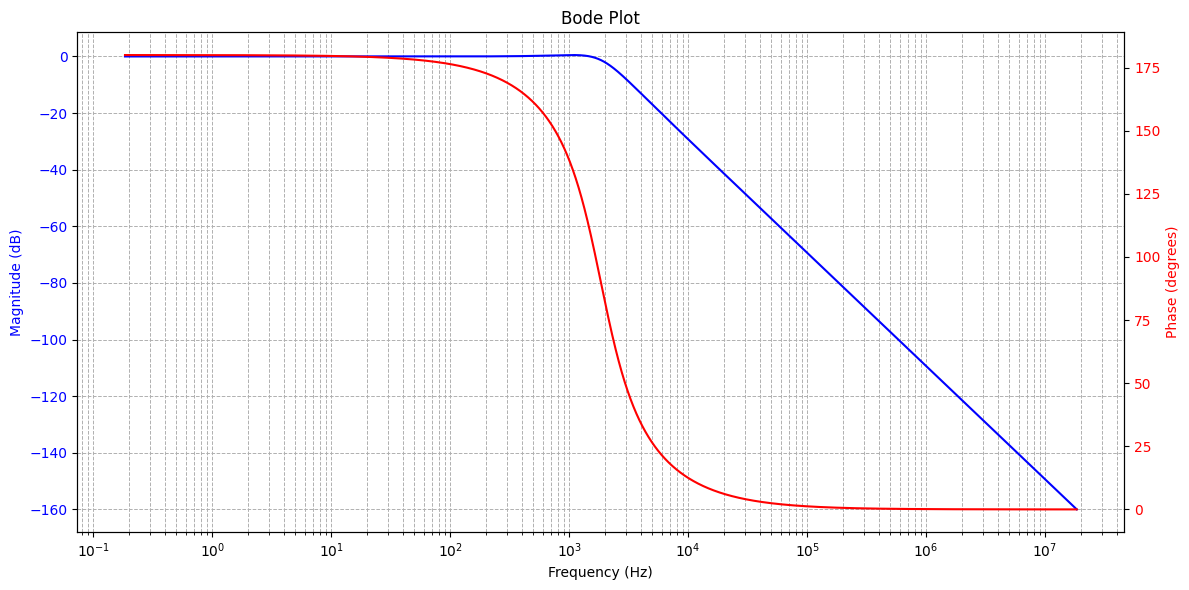


Ganancia en $\omega_{s}$ = (4500.0): -15.098[dB]

Ganancia en $\omega_{c}$ = (1500.0): -0.007[dB]


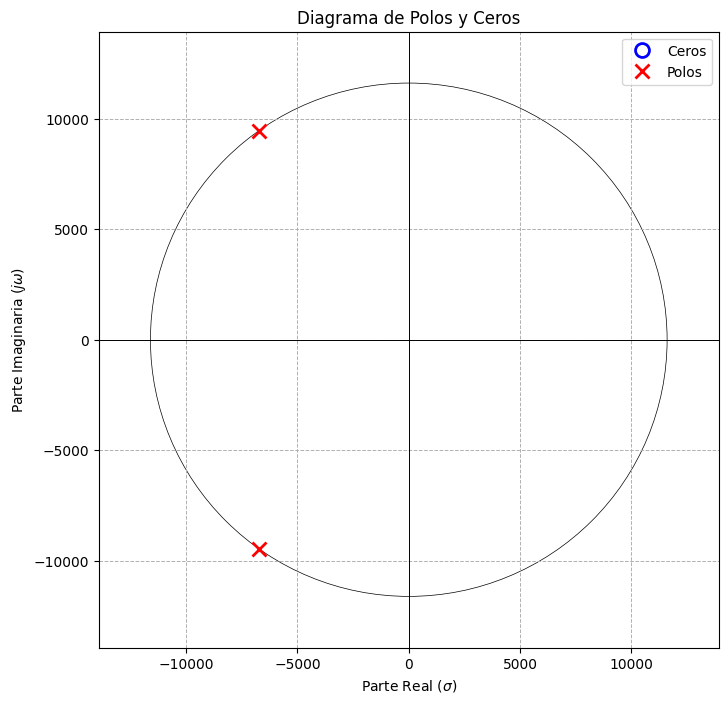


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R_3$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 11605.11[rad/s]$:
$$R_3 = 8.62 k\Omega$$
### Valor numérico de $R_1 = \frac{R_3}{k}$:
$$R_1 = 9.13 k\Omega$$
### Valor numérico de $R_2 = Q \cdot R_3$:
$$R_2 = 7.44 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


In [4]:
w_cheby = np.sqrt(1.5162)
fc = 1.5e3
w_c = 2 * np.pi * fc
_w0 = w_cheby * w_c

_Q = 0.863
_k = 0.9438

components = {"C": 1 / _w0, "R1": 1 / _k, "R2": _Q, "R3": 1}
T, _ = usynth.synth_ackerberg_mossberg(components=components)
(magnitude_db, frequencies, _) = uplt.plot_tf(T, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - (3 * w_c) / (2 * np.pi)))
magnitude_at_ws = magnitude_db[idx]
idx = np.argmin(np.abs(frequencies - (1 * w_c) / (2 * np.pi)))
magnitude_at_wc = magnitude_db[idx]

markdown_text = rf"""
Ganancia en $\omega_{{s}}$ = ({(3 * w_c) / (2 * np.pi)}): {magnitude_at_ws:.3f}[dB]

Ganancia en $\omega_{{c}}$ = ({(1 * w_c) / (2 * np.pi)}): {magnitude_at_wc:.3f}[dB]
"""

display(Markdown(markdown_text))

_ = uplt.plot_polos_ceros(T, _w0, {})

usynth.get_values_ackerberg_mossberg(C_forced=10e-9, _w0=_w0, _Q=_Q, _k=_k)

Valores comerciales:
- $7k5$
- $9k1$
- $8k2 + 390$

# Síntesis - Orden 3

In [5]:
from scipy.signal import TransferFunction, cheby1

# Se puede utilizar la funcion cheby1 de scipy.signal con w = 1 para tener los coeficientes
# de la transferencia.
b, a = cheby1(N=3, rp=0.5, Wn=[1], btype="lowpass", analog=True, output="ba")

tf = TransferFunction(b, a)
s = sp.symbols("s")
B = sum(coef * s**i for i, coef in enumerate(reversed(b)))
A = sum(coef * s**i for i, coef in enumerate(reversed(a)))

markdown_text = rf"""`
### Transferencia Chebyshev con `scipy.signal.cheby1`, igual a la obtenida a manualmente:
$$
H(s) = {sp.latex(B/A)}
$$
"""
display(Markdown(markdown_text))

`
### Transferencia Chebyshev con `scipy.signal.cheby1`, igual a la obtenida a manualmente:
$$
H(s) = \frac{0.715693790310797}{1.0 s^{3} + 1.25291297268055 s^{2} + 1.53489545855561 s + 0.715693790310797}
$$


In [6]:
T1, T2 = ut.lp_sos_sections(b, a)
markdown_text = rf"""
### Verificación de la transferencia de Chebyshev:
$$
H(s) = {sp.latex(T1 * T2)}
$$
"""
display(Markdown(markdown_text))

$$H_{1}(s) = \frac{0.626}{1.0 s + 0.626}$$

$$H_{2}(s) = \frac{1.14}{1.0 s^{2} + 0.626 s + 1.14}$$


### Verificación de la transferencia de Chebyshev:
$$
H(s) = \frac{0.715693790310797}{\left(1.0 s + 0.626456486340275\right) \left(1.0 s^{2} + 0.626456486340274 s + 1.1424477292778\right)}
$$


In [7]:
fc = 1.5e3
w_c = 2 * np.pi * fc

denom2 = sp.denom(T2)
denom2 = sp.expand(denom2)
terms = denom2.as_ordered_terms()
w = sp.sqrt(terms[-1])
w_over_Q = terms[-2] / s
_Q = w / w_over_Q
_k = 1
_w0 = w * w_c

components = {"C": 1 / _w0, "R1": 1 / _k, "R2": _Q, "R3": 1}
T2_eval, _ = usynth.synth_ackerberg_mossberg(components=components)
usynth.get_values_ackerberg_mossberg(C_forced=10e-9, _w0=_w0, _Q=_Q, _k=_k)

$$\Omega_Z = R_3 == 1$$


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R_3$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 10073.71[rad/s]$:
$$R_3 = 9.93 k\Omega$$
### Valor numérico de $R_1 = \frac{R_3}{k}$:
$$R_1 = 9.93 k\Omega$$
### Valor numérico de $R_2 = Q \cdot R_3$:
$$R_2 = 16.9 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


In [8]:
denom1 = sp.denom(T1)
denom1 = sp.expand(denom1)
terms = denom1.as_ordered_terms()
w = sp.sqrt(terms[-1])
_w0 = w * w_c

T1_eval = usynth.synth_RC(_w0)
usynth.get_values_RC(_w0, C_forced=10e-9)


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 7459.62[rad/s]$:
$$R = 13.4 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


$$H(s) = -7.57E^{11} \frac{1}{1s^3 + 1.34E^{4}s^2 + 1.46E^{8}s + 7.57E^{11}}$$

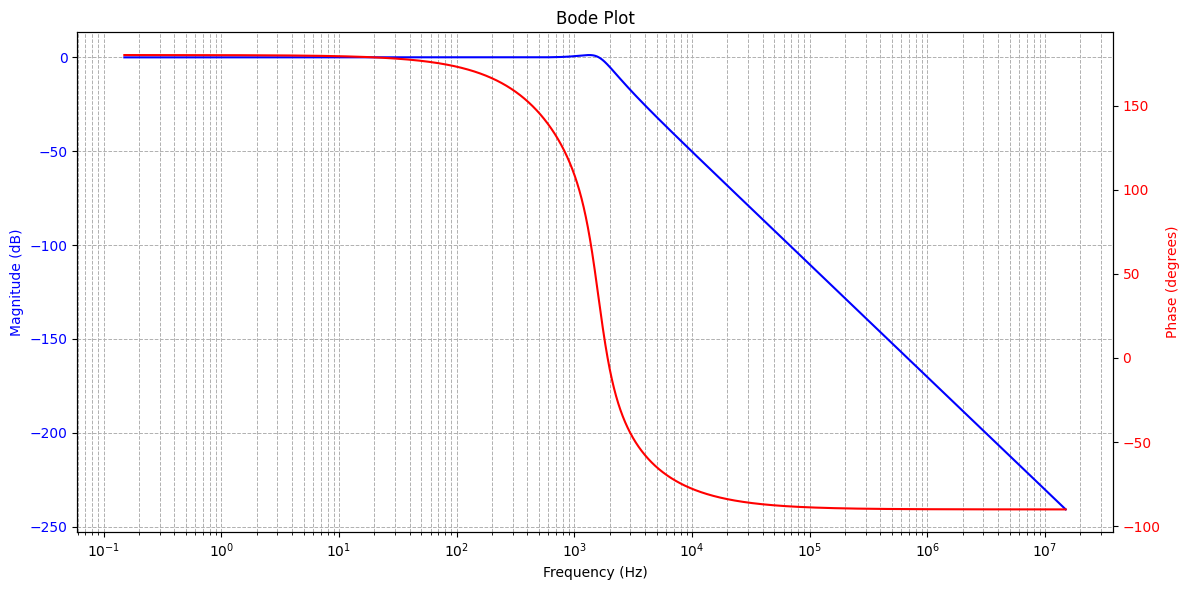


Ganancia en $\omega_{s}$ = (4500.0): -28.866[dB]

Ganancia en $\omega_{c}$ = (1500.0): 0.861[dB]


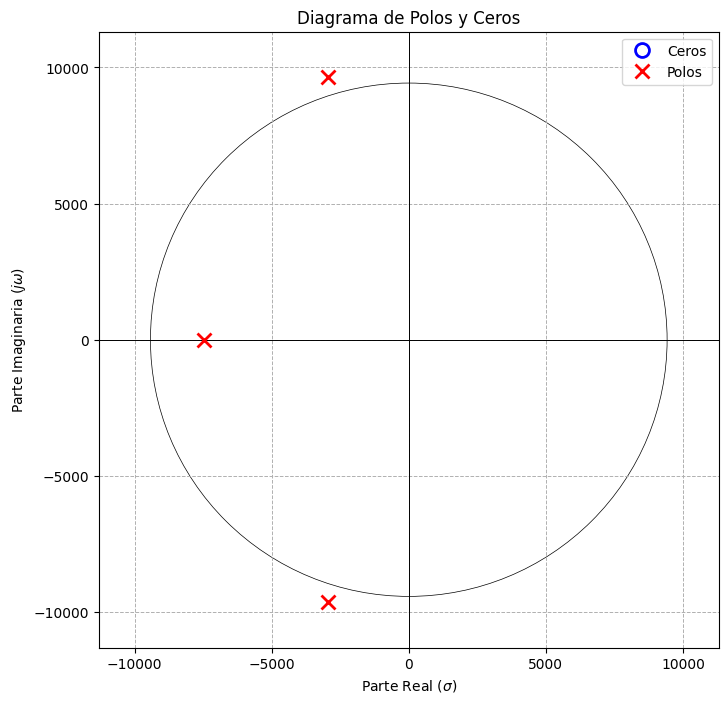

In [ ]:
T3_eval = T1_eval * T2_eval
w = sp.sqrt(terms[-1])
(magnitude_db, frequencies, _) = uplt.plot_tf(T3_eval, {}, w_c / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - (3 * w_c) / (2 * np.pi)))
magnitude_at_ws = magnitude_db[idx]
idx = np.argmin(np.abs(frequencies - (1 * w_c) / (2 * np.pi)))
magnitude_at_wc = magnitude_db[idx]

markdown_text = rf"""
Ganancia en $\omega_{{s}}$ = ({(3 * w_c) / (2 * np.pi)}): {magnitude_at_ws:.3f}[dB]

Ganancia en $\omega_{{c}}$ = ({(1 * w_c) / (2 * np.pi)}): {magnitude_at_wc:.3f}[dB]
"""

display(Markdown(markdown_text))

_ = uplt.plot_polos_ceros(T3_eval, w_c, {})

### Simulación con LT Spice - Orden 3

Circuito:

<div align=center>

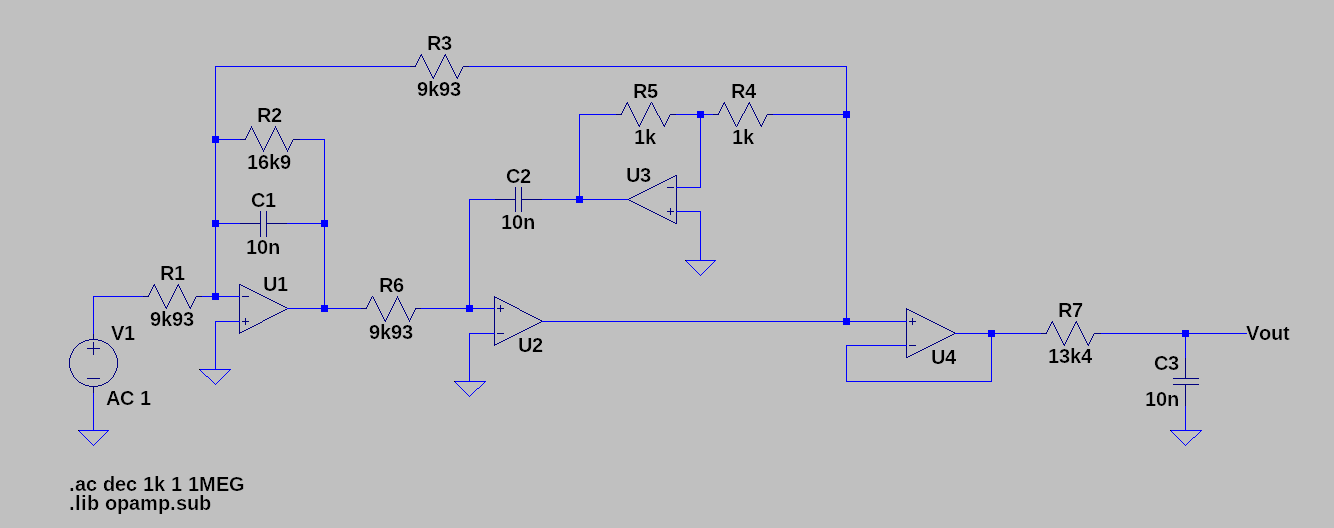

</div>

Módulo y Fase:

<div align=center>

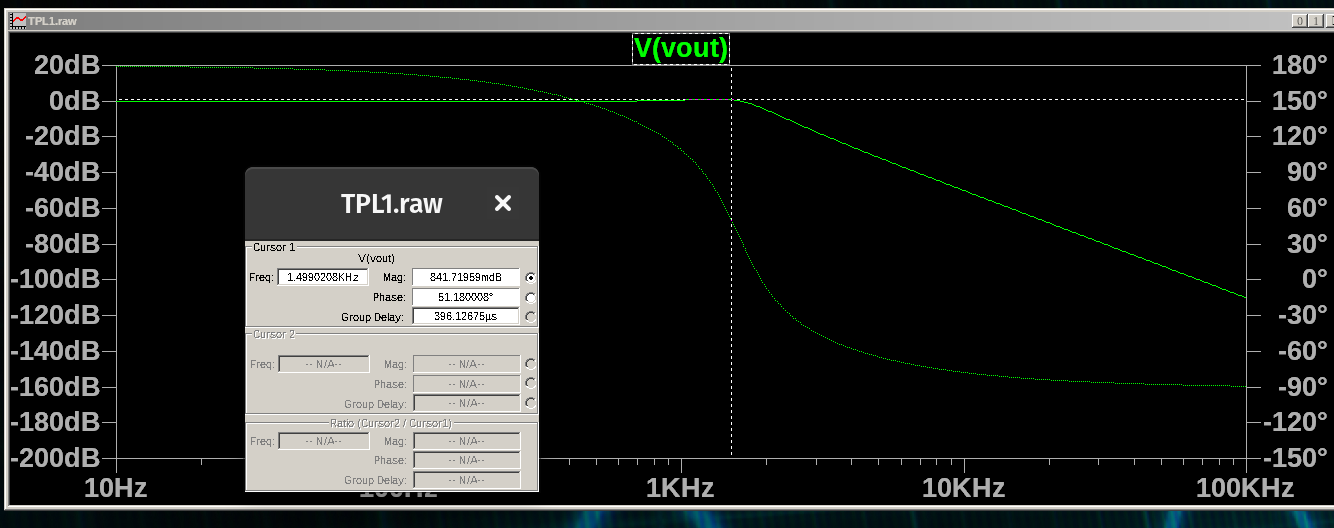

</div>

<a href="./TPL1.asc" download="TPL1.asc">Descargar TPL1.asc</a>